# Notebook 00: Exploratory Data Analysis (EDA)

**Objective:** Before building causal models, we need to understand the data — distributions, correlations, potential confounding patterns, and seasonality. This EDA serves two purposes:

1. **Sanity check** the synthetic data generator
2. **Build intuition** for the causal graph we'll define in Notebook 01

> **Why EDA matters for causal inference:** Causal models require us to specify which variables are confounders, mediators, or colliders. EDA helps us spot correlations that suggest confounding (e.g., brand equity correlating with both treatment assignment and outcomes) and guides our DAG construction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
pd.set_option("display.max_columns", 30)

df = pd.read_csv("../data/retail_data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (62400, 24)


,week_date,iso_year,iso_week,city_id,city_name,sku_id,brand,category,brand_equity,base_price,competitor_price_index,seasonality_multiplier,festival,is_festival_week,discount_depth,is_instore_display,local_channel_promo,sms_blast_active,loyalty_topup_discount,special_coupon_usage,is_2x_points_active,sales_volume,revenue,profit_margin
0,2021-01-04,2021,1,1,Mumbai,SKU_001,Parle,Namkeen,0.574507,225.0,1.0222,1.08,NaN,0,0.0894,0,0,0,0.0624,0.1692,0,908.2,186075.18,0.2076
1,2021-01-04,2021,1,1,Mumbai,SKU_002,Britannia,Biscuits,0.479260,64.0,1.0222,1.08,NaN,0,0.1434,0,0,0,0.0496,0.2186,0,849.0,46544.15,0.1953
2,2021-01-04,2021,1,1,Mumbai,SKU_003,ITC,Sweets,0.736882,26.0,1.0222,1.08,NaN,0,0.1586,1,0,0,0.0577,0.1204,0,1046.5,22893.16,0.1792
3,2021-01-04,2021,1,1,Mumbai,SKU_004,Haldirams,Biscuits,0.615115,253.0,1.0222,1.08,NaN,0,0.0661,1,0,0,0.0378,0.1503,0,1033.7,244244.66,0.2650
4,2021-01-04,2021,1,1,Mumbai,SKU_005,Bikaji,Namkeen,0.430487,105.0,1.0222,1.08,NaN,0,0.1450,0,0,0,0.0395,0.2696,0,884.6,79416.60,0.1967


In [2]:
# Quick data overview
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().any().any() else "No missing values")
print("\n=== Summary Statistics ===")
df.describe().round(3)

=== Data Types ===


week_date                  object
iso_year                    int64
iso_week                    int64
city_id                     int64
city_name                  object
sku_id                     object
brand                      object
category                   object
brand_equity              float64
base_price                float64
competitor_price_index    float64
seasonality_multiplier    float64
festival                   object
is_festival_week            int64
discount_depth            float64
is_instore_display          int64
local_channel_promo         int64
sms_blast_active            int64
loyalty_topup_discount    float64
special_coupon_usage      float64
is_2x_points_active         int64
sales_volume              float64
revenue                   float64
profit_margin             float64
dtype: object

=== Missing Values ===
festival    51600
dtype: int64

=== Summary Statistics ===


,iso_year,iso_week,city_id,brand_equity,base_price,competitor_price_index,seasonality_multiplier,is_festival_week,discount_depth,is_instore_display,local_channel_promo,sms_blast_active,loyalty_topup_discount,special_coupon_usage,is_2x_points_active,sales_volume,revenue,profit_margin
count,62400.000,62400.000,62400.000,62400.000,62400.000,62400.000,62400.000,62400.000,62400.000,62400.000,62400.000,62400.000,62400.000,62400.000,62400.000,62400.000,62400.000,62400.000
mean,2022.000,26.500,2.500,0.521,161.150,1.003,1.028,0.173,0.139,0.314,0.193,0.213,0.041,0.160,0.128,862.284,118351.979,0.198
std,0.817,15.008,1.118,0.127,79.303,0.049,0.109,0.378,0.065,0.464,0.394,0.409,0.020,0.080,0.334,151.759,61286.020,0.052
min,2021.000,1.000,1.000,0.196,21.000,0.872,0.920,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,478.900,10550.710,0.020
25%,2021.000,13.750,1.750,0.432,100.750,0.974,0.947,0.000,0.093,0.000,0.000,0.000,0.027,0.103,0.000,754.700,68379.865,0.164
50%,2022.000,26.500,2.500,0.538,164.000,1.005,1.019,0.000,0.134,0.000,0.000,0.000,0.040,0.159,0.000,838.700,114459.920,0.201
75%,2023.000,39.250,3.250,0.605,227.750,1.032,1.071,0.000,0.180,1.000,0.000,0.000,0.054,0.214,0.000,943.400,164255.660,0.234
max,2023.000,52.000,4.000,0.829,296.000,1.134,1.568,1.000,0.400,1.000,1.000,1.000,0.100,0.499,1.000,1680.800,381739.790,0.374


## 1. Outcome Distributions

We have three outcome variables:
- **sales_volume**: Units sold per SKU per city per week
- **revenue**: sales_volume × effective price
- **profit_margin**: Net margin after discount erosion and promo costs

We expect right-skewed distributions (most weeks are "normal", festival weeks push the tail).

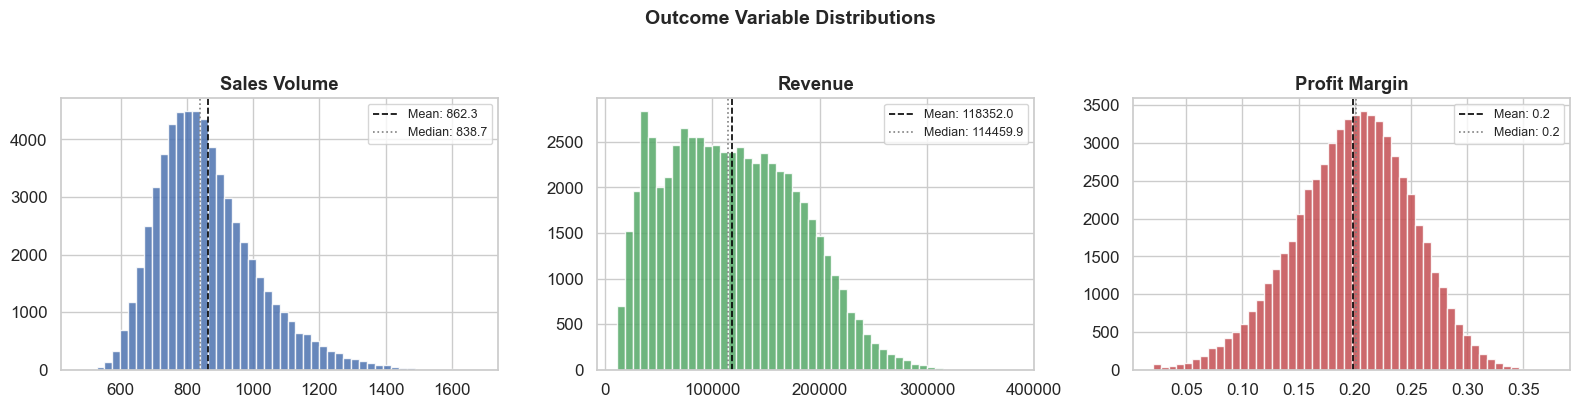

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
outcomes = ["sales_volume", "revenue", "profit_margin"]
colors = ["#4C72B0", "#55A868", "#C44E52"]

for ax, col, color in zip(axes, outcomes, colors):
    df[col].hist(bins=50, ax=ax, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(df[col].mean(), color="black", ls="--", lw=1.2, label=f"Mean: {df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="gray", ls=":", lw=1.2, label=f"Median: {df[col].median():.1f}")
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle("Outcome Variable Distributions", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2. Outcome Distributions by City

Different cities have different base demands. Mumbai and Delhi should show higher volumes than Bengaluru and Hyderabad.

C:\Users\ACER\AppData\Local\Temp\ipykernel_26444\1066042014.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="city_name", y=col, ax=ax, palette="Set2", showfliers=False)


C:\Users\ACER\AppData\Local\Temp\ipykernel_26444\1066042014.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="city_name", y=col, ax=ax, palette="Set2", showfliers=False)
C:\Users\ACER\AppData\Local\Temp\ipykernel_26444\1066042014.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="city_name", y=col, ax=ax, palette="Set2", showfliers=False)


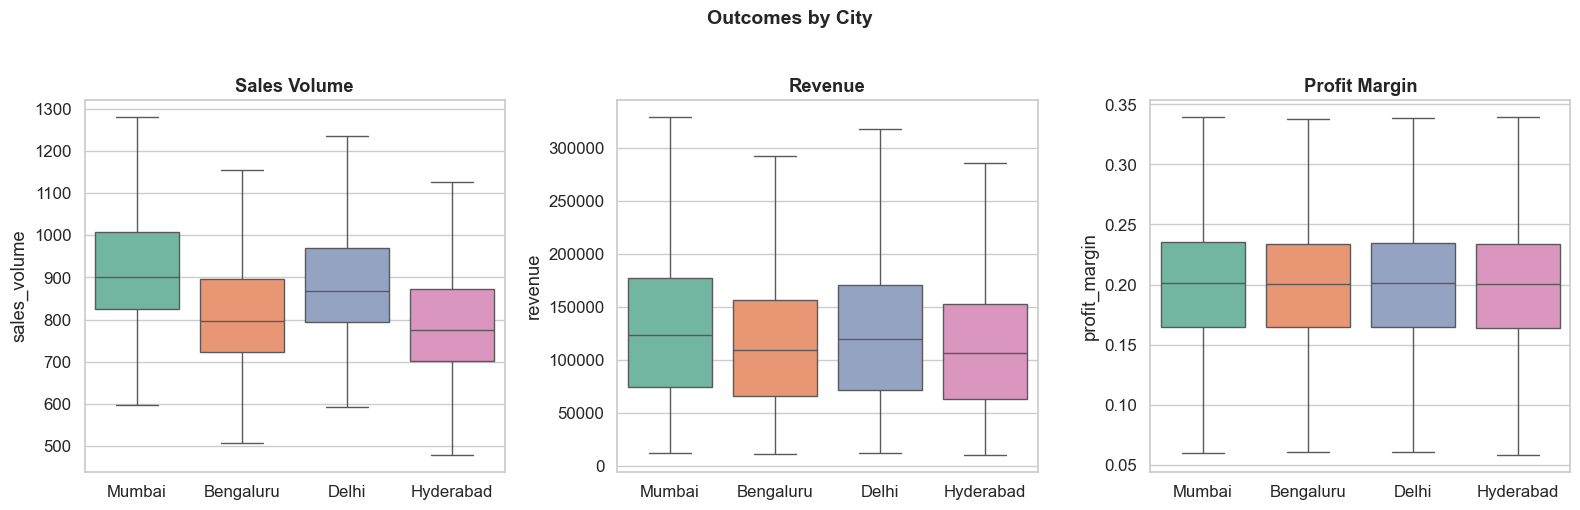

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, outcomes):
    sns.boxplot(data=df, x="city_name", y=col, ax=ax, palette="Set2", showfliers=False)
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("")

fig.suptitle("Outcomes by City", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Treatment Variable Distributions

**Why this matters for causal inference:** If treatments are not randomly assigned (and in retail, they never are), we need to understand what drives treatment assignment. This is the "selection bias" we'll correct for using the Backdoor Criterion.

We expect:
- Higher brand equity SKUs → more in-store displays and promos
- Festival weeks → more aggressive promotions across all levers

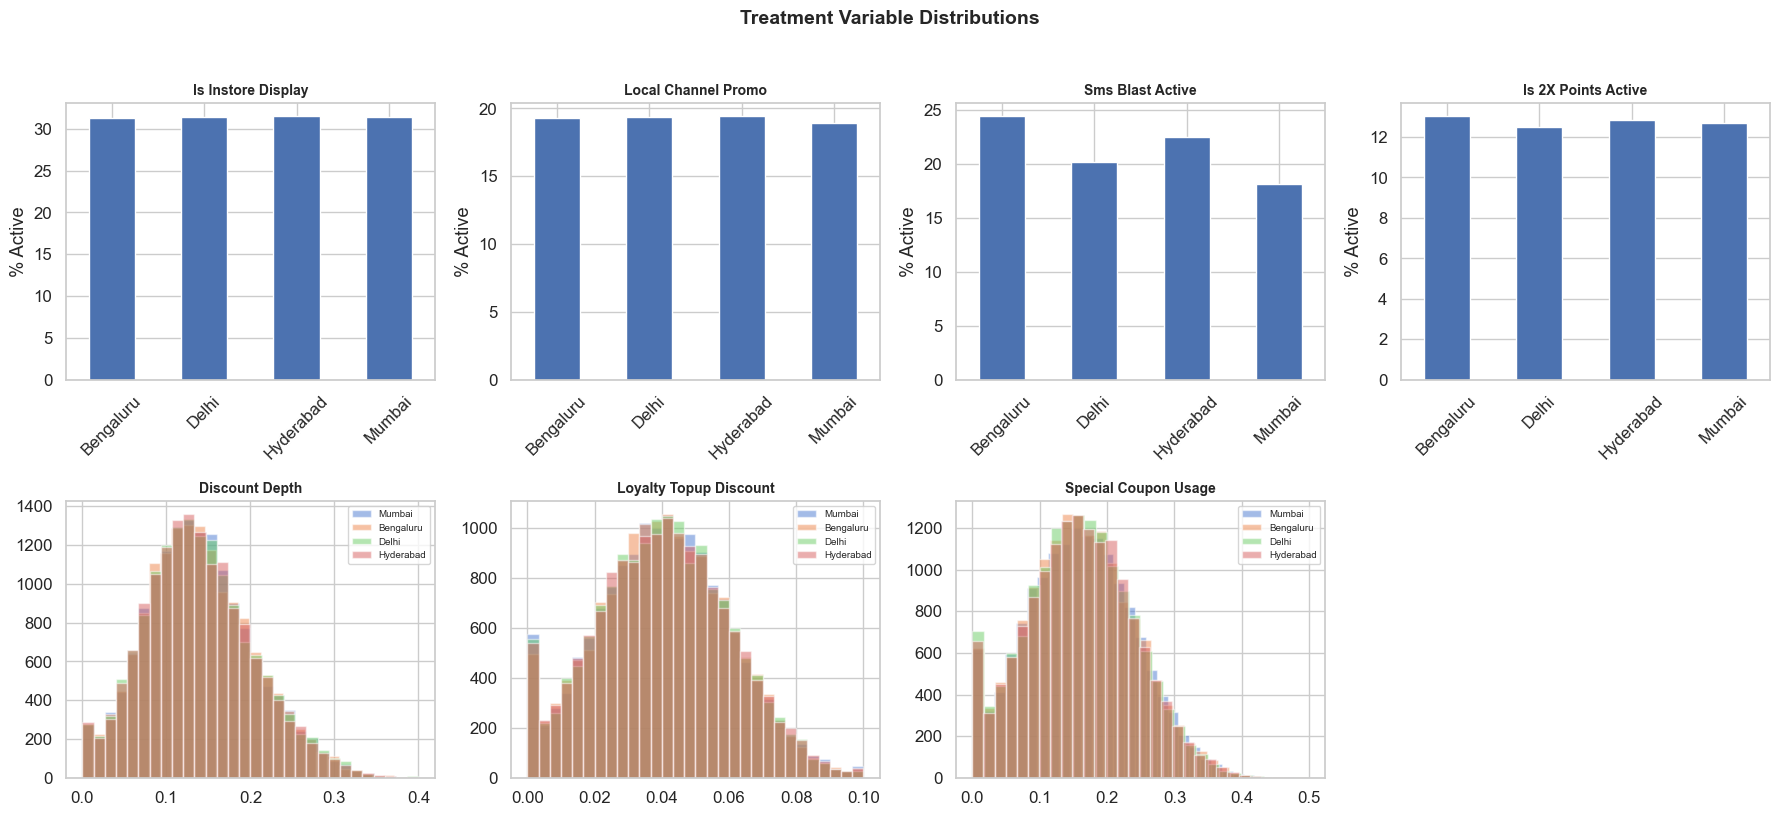

In [5]:
treatment_binary = ["is_instore_display", "local_channel_promo", "sms_blast_active", "is_2x_points_active"]
treatment_continuous = ["discount_depth", "loyalty_topup_discount", "special_coupon_usage"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Row 1: Binary treatment rates by city
for ax, col in zip(axes[0], treatment_binary):
    rates = df.groupby("city_name")[col].mean() * 100
    rates.plot.bar(ax=ax, color="#4C72B0", edgecolor="white")
    ax.set_title(col.replace("_", " ").title(), fontweight="bold", fontsize=10)
    ax.set_ylabel("% Active")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)

# Row 2: Continuous treatment distributions
for i, col in enumerate(treatment_continuous):
    ax = axes[1][i]
    for city in df["city_name"].unique():
        subset = df[df["city_name"] == city][col]
        ax.hist(subset, bins=30, alpha=0.5, label=city, edgecolor="white")
    ax.set_title(col.replace("_", " ").title(), fontweight="bold", fontsize=10)
    ax.legend(fontsize=7)

axes[1][3].axis("off")
fig.suptitle("Treatment Variable Distributions", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Confounding Evidence: Treatment Assignment vs. Confounders

This is the critical EDA step for causal inference. If treatments are correlated with confounders, naive regression will be biased. We check:
- **Brand equity → treatment**: Do high-equity brands get more promos?
- **Festival → treatment**: Are promos more frequent during festivals?

If we see these patterns, it **confirms the need for causal methods** (not just correlation).

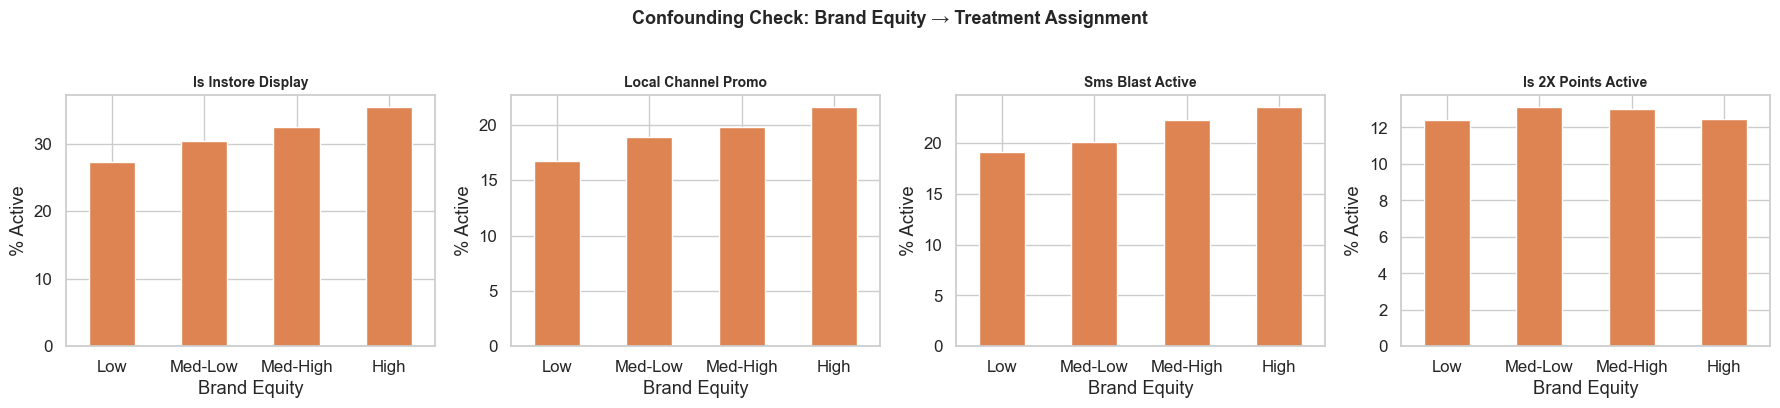

Interpretation: If bars increase left-to-right, brand equity confounds treatment assignment.


In [6]:
# Brand equity bins vs treatment rates
df["brand_equity_bin"] = pd.qcut(df["brand_equity"], q=4, labels=["Low", "Med-Low", "Med-High", "High"])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, treatment_binary):
    rates = df.groupby("brand_equity_bin", observed=True)[col].mean() * 100
    rates.plot.bar(ax=ax, color="#DD8452", edgecolor="white")
    ax.set_title(col.replace("_", " ").title(), fontweight="bold", fontsize=10)
    ax.set_ylabel("% Active")
    ax.set_xlabel("Brand Equity")
    ax.tick_params(axis='x', rotation=0)

fig.suptitle("Confounding Check: Brand Equity → Treatment Assignment", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Interpretation: If bars increase left-to-right, brand equity confounds treatment assignment.")

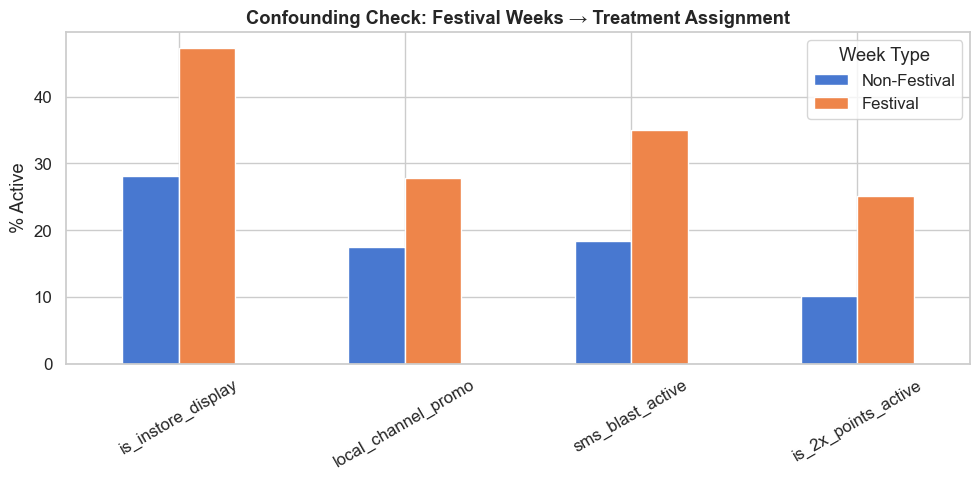


Avg discount depth - Non-festival: 0.122
Avg discount depth - Festival:     0.222


In [7]:
# Festival vs non-festival treatment rates
fig, ax = plt.subplots(figsize=(10, 5))
all_treatments = treatment_binary + ["discount_depth"]

festival_rates = df.groupby("is_festival_week")[treatment_binary].mean() * 100
festival_rates.index = ["Non-Festival", "Festival"]
festival_rates.T.plot.bar(ax=ax, edgecolor="white")
ax.set_ylabel("% Active")
ax.set_title("Confounding Check: Festival Weeks → Treatment Assignment", fontweight="bold")
ax.tick_params(axis='x', rotation=30)
ax.legend(title="Week Type")
plt.tight_layout()
plt.show()

# Discount depth during festivals vs non-festivals
print(f"\nAvg discount depth - Non-festival: {df[df['is_festival_week']==0]['discount_depth'].mean():.3f}")
print(f"Avg discount depth - Festival:     {df[df['is_festival_week']==1]['discount_depth'].mean():.3f}")

## 5. Correlation Matrix & Multicollinearity (VIF)

**Why VIF matters for causal inference:** If treatment variables are highly correlated with each other (multicollinearity), it becomes hard to disentangle their individual causal effects. VIF > 5 is a warning sign; VIF > 10 indicates severe multicollinearity.

We compute the correlation matrix across all numeric features, then VIF for the key analysis variables.

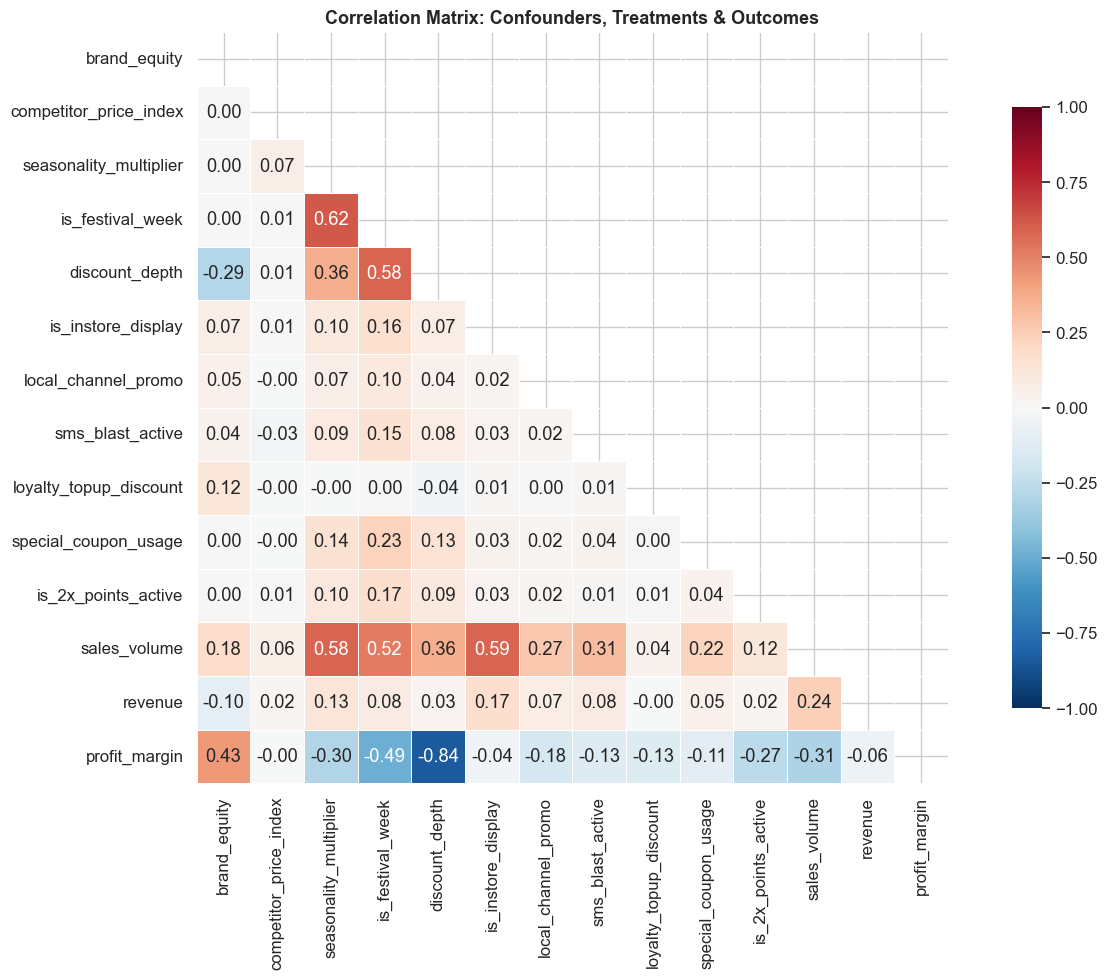

In [8]:
# Correlation heatmap for analysis variables
analysis_cols = [
    "brand_equity", "competitor_price_index", "seasonality_multiplier", "is_festival_week",
    "discount_depth", "is_instore_display", "local_channel_promo", "sms_blast_active",
    "loyalty_topup_discount", "special_coupon_usage", "is_2x_points_active",
    "sales_volume", "revenue", "profit_margin"
]

corr = df[analysis_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix: Confounders, Treatments & Outcomes", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# Variance Inflation Factor (VIF)
vif_cols = [
    "brand_equity", "competitor_price_index", "seasonality_multiplier", "is_festival_week",
    "discount_depth", "is_instore_display", "local_channel_promo", "sms_blast_active",
    "loyalty_topup_discount", "special_coupon_usage", "is_2x_points_active",
]
vif_data = df[vif_cols].dropna()
vif_results = pd.DataFrame({
    "Variable": vif_cols,
    "VIF": [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_cols))]
}).sort_values("VIF", ascending=False)

print("=== Variance Inflation Factors ===")
print("VIF > 5: moderate concern | VIF > 10: severe multicollinearity\n")
print(vif_results.to_string(index=False))

=== Variance Inflation Factors ===
VIF > 5: moderate concern | VIF > 10: severe multicollinearity

              Variable        VIF
competitor_price_index 133.460319
seasonality_multiplier 121.229047
          brand_equity  19.959067
        discount_depth   9.316458
loyalty_topup_discount   5.231891
  special_coupon_usage   5.184606
      is_festival_week   2.566510
    is_instore_display   1.501991
      sms_blast_active   1.303274
   local_channel_promo   1.253899
   is_2x_points_active   1.180673


## 6. Seasonality Patterns

Visualize the weekly time series of average sales volume to confirm:
- Festival weeks produce clear spikes
- There's a mild annual cycle (monsoon dip, winter lift)

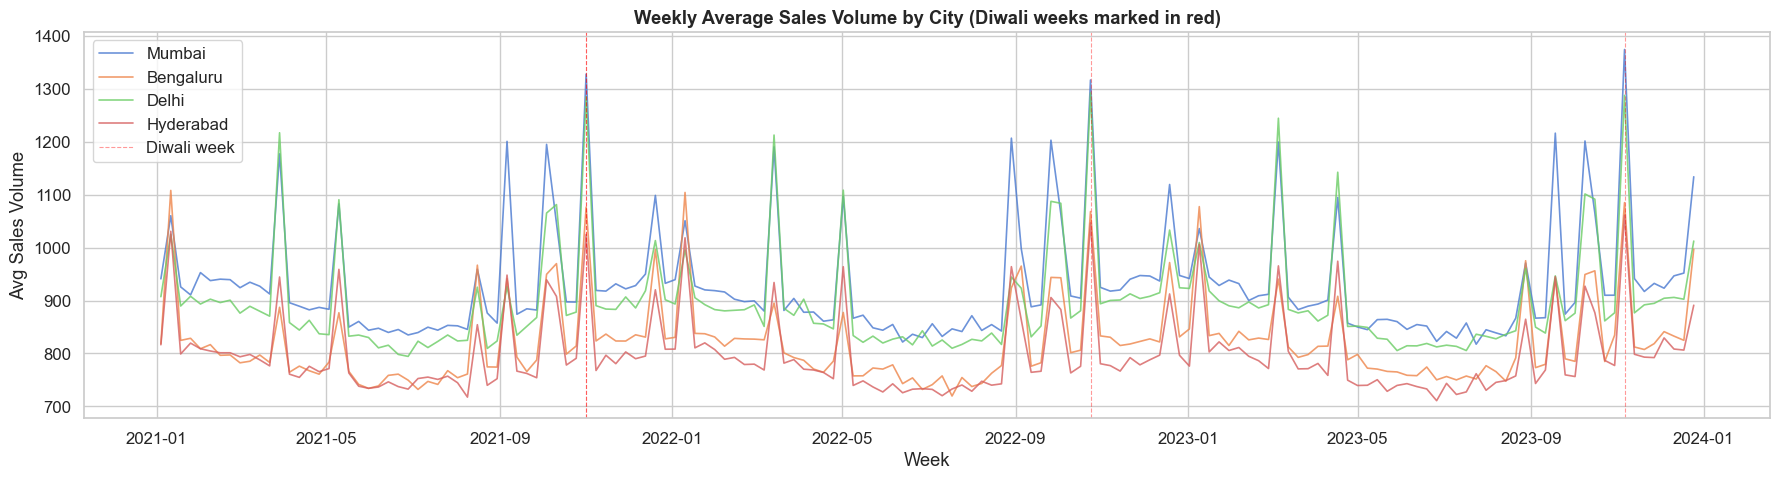

In [10]:
# Weekly average sales volume by city over time
weekly_city = df.groupby(["week_date", "city_name"])["sales_volume"].mean().reset_index()
weekly_city["week_date"] = pd.to_datetime(weekly_city["week_date"])

fig, ax = plt.subplots(figsize=(18, 5))
for city in ["Mumbai", "Bengaluru", "Delhi", "Hyderabad"]:
    subset = weekly_city[weekly_city["city_name"] == city]
    ax.plot(subset["week_date"], subset["sales_volume"], label=city, alpha=0.8, lw=1.2)

# Mark Diwali weeks
diwali_dates = ["2021-11-01", "2022-10-24", "2023-11-06"]
for d in diwali_dates:
    ax.axvline(pd.to_datetime(d), color="red", ls="--", alpha=0.4, lw=0.8)
ax.axvline(pd.to_datetime(diwali_dates[0]), color="red", ls="--", alpha=0.4, lw=0.8, label="Diwali week")

ax.set_title("Weekly Average Sales Volume by City (Diwali weeks marked in red)", fontweight="bold")
ax.set_xlabel("Week")
ax.set_ylabel("Avg Sales Volume")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Treatment → Outcome (Naive Visual Check)

These scatter/box plots show the **raw** (unadjusted) relationship between treatments and outcomes. 

**Warning:** These are NOT causal effects — they are confounded. The whole point of Notebooks 01 and 02 is to remove the confounding and recover the true causal effect. But these naive views help us see:
- The direction of the raw association
- Whether there's enough variation in treatment for identification

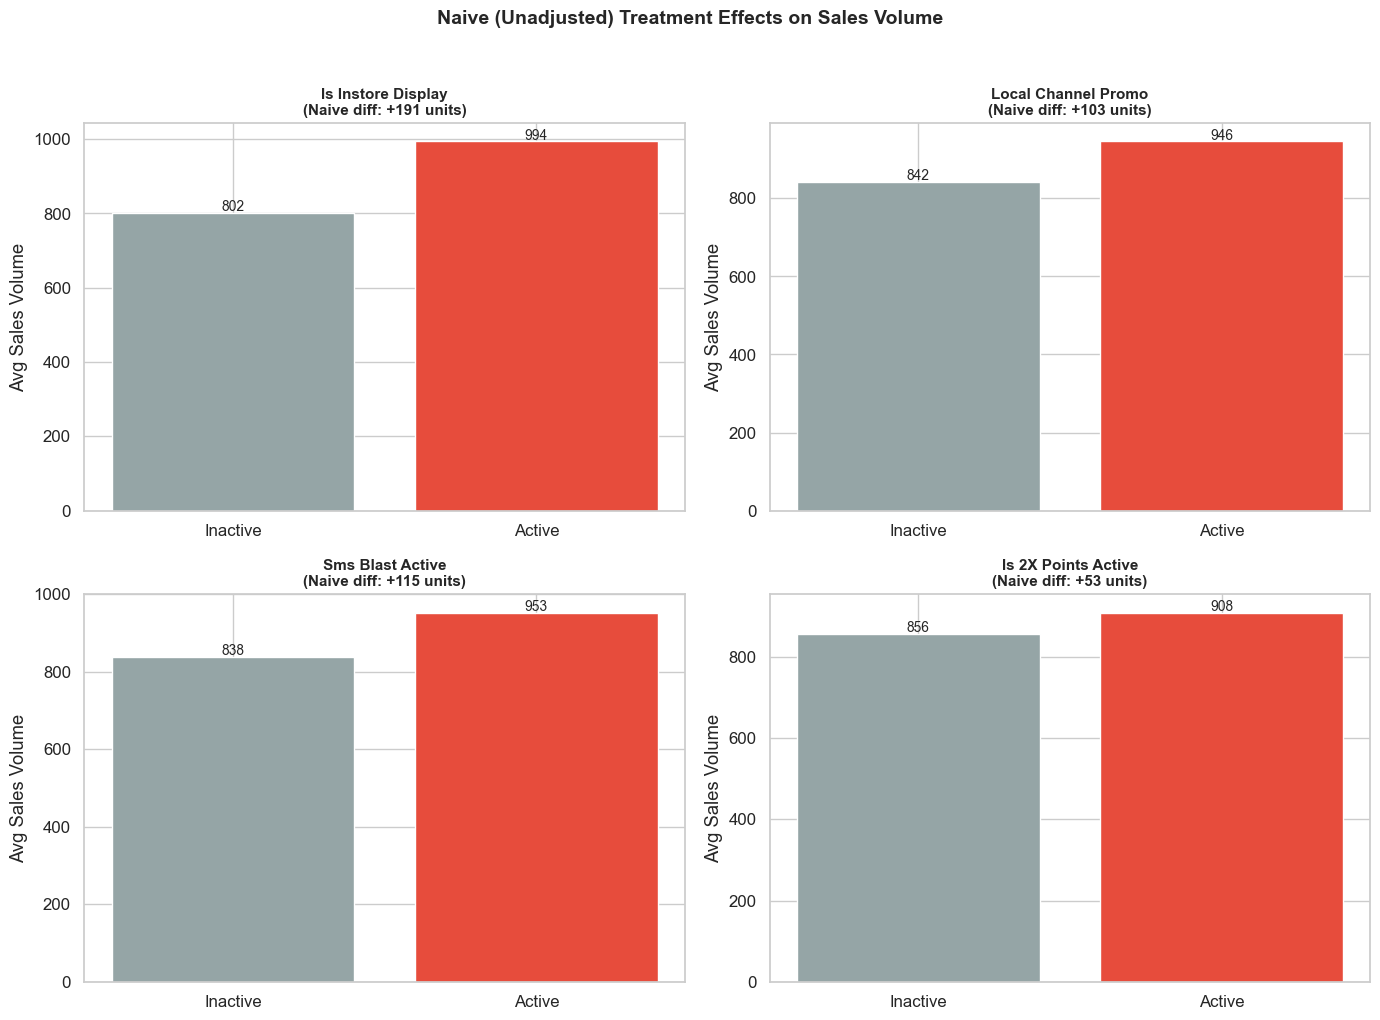

⚠ These differences are CONFOUNDED — brand equity and festivals drive both treatment and outcome.


In [11]:
# Binary treatments vs sales volume
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, treatment_binary):
    means = df.groupby(col)["sales_volume"].mean()
    bars = ax.bar(["Inactive", "Active"], means.values, color=["#95a5a6", "#e74c3c"], edgecolor="white")
    diff = means.values[1] - means.values[0]
    ax.set_title(f"{col.replace('_', ' ').title()}\n(Naive diff: +{diff:.0f} units)", fontweight="bold", fontsize=11)
    ax.set_ylabel("Avg Sales Volume")
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f"{val:.0f}", ha="center", fontsize=10)

fig.suptitle("Naive (Unadjusted) Treatment Effects on Sales Volume", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("⚠ These differences are CONFOUNDED — brand equity and festivals drive both treatment and outcome.")

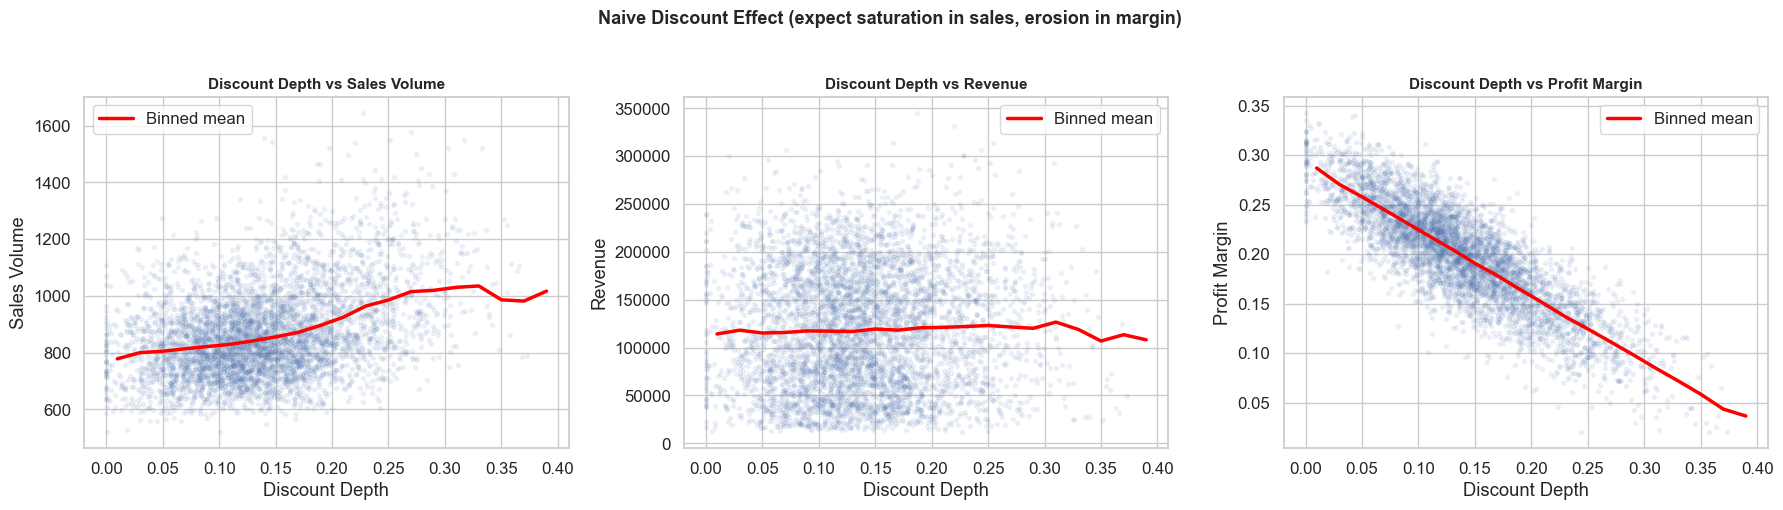

In [12]:
# Discount depth vs sales volume (scatter with LOESS-like binned average)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, outcome in zip(axes, outcomes):
    ax.scatter(df["discount_depth"].sample(5000, random_state=42),
               df[outcome].sample(5000, random_state=42),
               alpha=0.08, s=8, color="#4C72B0")
    # Binned average overlay
    df["disc_bin_fine"] = pd.cut(df["discount_depth"], bins=20)
    binned = df.groupby("disc_bin_fine", observed=True)[outcome].mean()
    bin_centers = [interval.mid for interval in binned.index]
    ax.plot(bin_centers, binned.values, color="red", lw=2.5, label="Binned mean")
    ax.set_xlabel("Discount Depth")
    ax.set_ylabel(outcome.replace("_", " ").title())
    ax.set_title(f"Discount Depth vs {outcome.replace('_', ' ').title()}", fontweight="bold", fontsize=11)
    ax.legend()

df.drop(columns=["disc_bin_fine"], inplace=True)
fig.suptitle("Naive Discount Effect (expect saturation in sales, erosion in margin)", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Interaction Effects (Visual Preview)

The data generator embeds non-linear interactions. Let's visualize the SMS + Display synergy and the Loyalty 2x points + coupon interaction.

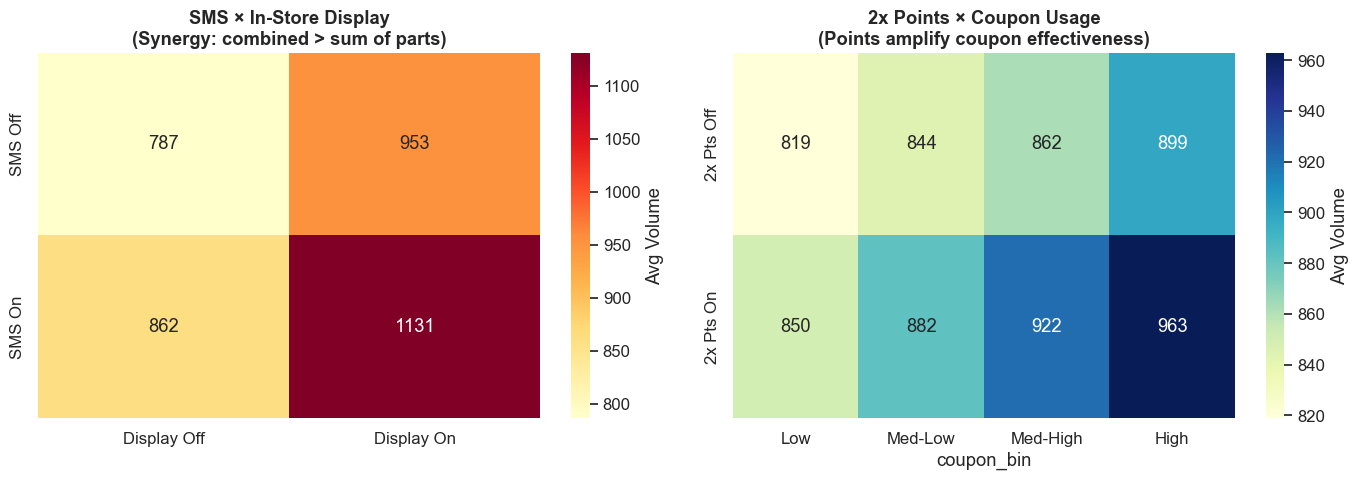

In [13]:
# SMS + Display interaction heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: SMS x Display
combo1 = df.groupby(["sms_blast_active", "is_instore_display"])["sales_volume"].mean().unstack()
combo1.index = ["SMS Off", "SMS On"]
combo1.columns = ["Display Off", "Display On"]
sns.heatmap(combo1, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[0], cbar_kws={"label": "Avg Volume"})
axes[0].set_title("SMS × In-Store Display\n(Synergy: combined > sum of parts)", fontweight="bold")

# Right: 2x Points x Coupon usage (binned)
df["coupon_bin"] = pd.qcut(df["special_coupon_usage"], q=4, labels=["Low", "Med-Low", "Med-High", "High"])
combo2 = df.groupby(["is_2x_points_active", "coupon_bin"], observed=True)["sales_volume"].mean().unstack()
combo2.index = ["2x Pts Off", "2x Pts On"]
sns.heatmap(combo2, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[1], cbar_kws={"label": "Avg Volume"})
axes[1].set_title("2x Points × Coupon Usage\n(Points amplify coupon effectiveness)", fontweight="bold")

df.drop(columns=["coupon_bin"], inplace=True)
plt.tight_layout()
plt.show()

## 9. EDA Summary & Implications for Causal Modeling

### Key Findings:
1. **Confounding is present:** Brand equity and festival timing both drive treatment assignment AND outcomes. Naive estimates will be biased upward.
2. **Treatment variation is sufficient:** All levers have enough active/inactive observations across cities for identification.
3. **Non-linear effects visible:** Discount saturation and SMS+Display synergy are visible even in raw data.
4. **Multicollinearity is manageable:** VIF values should be below 5 for most variables, allowing separate identification of treatment effects.

### What This Means for Notebook 01 (Causal Graph):
- **Confounders to include in DAG:** `brand_equity`, `seasonality_multiplier`, `is_festival_week`, `competitor_price_index`, `city_id`
- **Treatment nodes:** `discount_depth`, `is_instore_display`, `local_channel_promo`, `sms_blast_active`, loyalty levers
- **Outcome nodes:** `sales_volume`, `revenue`, `profit_margin`
- **Key edges:** Confounders → Treatments (selection bias), Confounders → Outcomes (direct effect), Treatments → Outcomes (causal effect we want)

### Next Step: Notebook 01 — Define the causal DAG and validate it with conditional independence tests.